# Instructions:
1. Please either download the kaggle dataset and upload on Google drive(1gb)
2. Or Use kaggle for today's session

In [ ]:
# Data Path
data_dir="/content/drive/MyDrive/Intellipaat-Jan2026/dogs-vs-cats/"
train_data="/content/drive/MyDrive/Intellipaat-Jan2026/dogs-vs-cats/train" #-> Use, which you can split into train/test
test_data="/content/drive/MyDrive/Intellipaat-Jan2026/dogs-vs-cats/test1" #Only for kaggle submission, real world

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

import os

In [ ]:
test_files=os.listdir(test_data)

In [ ]:
filenames=os.listdir(train_data)

labels=[x.split(".")[0] for x in filenames]

In [ ]:
set(labels)

{'cat', 'dog'}

In [ ]:
data=pd.DataFrame({"filename":filenames, "labels":labels})

In [ ]:
data.shape

(25075, 2)

In [ ]:
data['labels'].value_counts()

,count
labels,
cat,12545
dog,12530


In [ ]:
data.head()

,filename,labels
0,dog.9647.jpg,dog
1,dog.9783.jpg,dog
2,dog.7777.jpg,dog
3,dog.8666.jpg,dog
4,dog.843.jpg,dog


In [ ]:
from PIL import Image

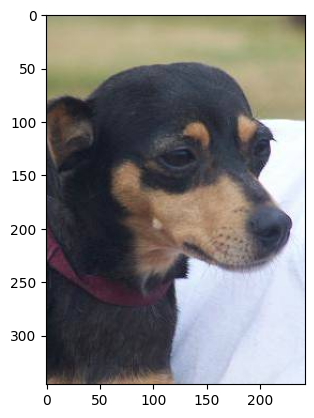

In [ ]:
img= Image.open(train_data+"/dog.9647.jpg")
plt.imshow(img)
plt.show()

In [ ]:
# Display random number of images of each class
def display_random_images(label="dog", num_images=5):

  filter_df=data[data['labels']==label]
  filter_df=filter_df.sample(num_images)

  for i in range(num_images):
    img=Image.open(train_data+"/"+filter_df.iloc[i]['filename'])
    print(np.array(img).shape)
    plt.imshow(img)
    plt.axis('off')
    plt.show()



(479, 336, 3)


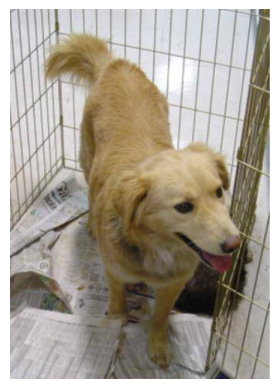

(483, 500, 3)


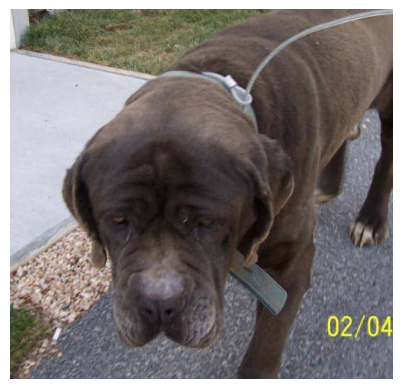

(200, 119, 3)


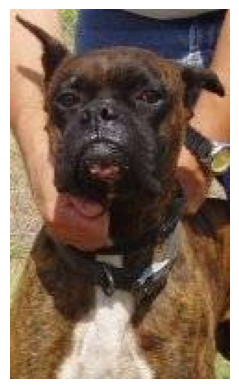

(353, 499, 3)


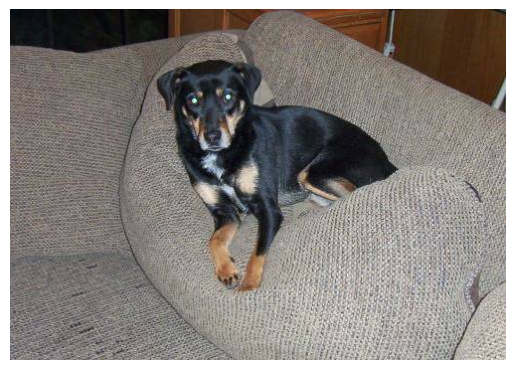

(237, 320, 3)


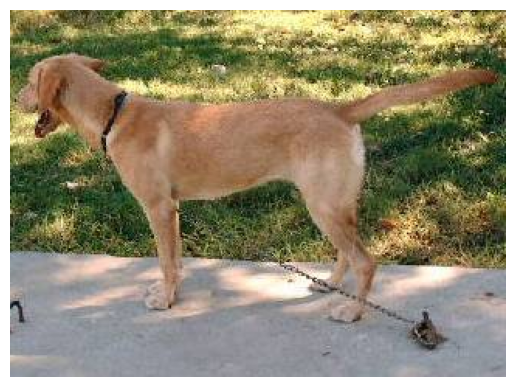

In [ ]:
display_random_images(label="dog", num_images=5)

(324, 284, 3)


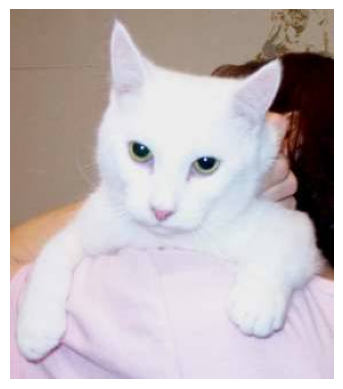

(497, 415, 3)


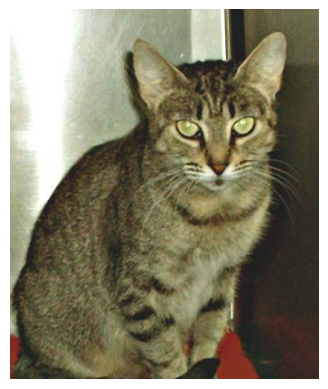

(378, 500, 3)


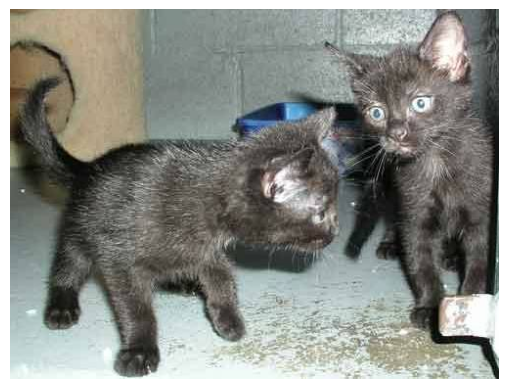

(324, 273, 3)


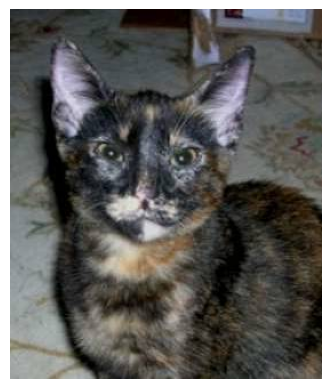

(374, 500, 3)


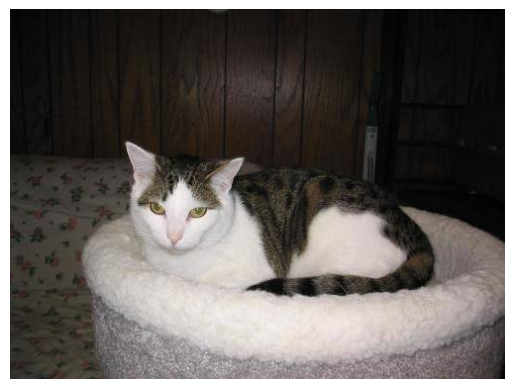

In [ ]:
display_random_images(label="cat", num_images=5)

In [ ]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df,test_df=train_test_split(data, test_size=0.3,random_state=42)

In [ ]:
train_df.shape

(17552, 2)

In [ ]:
test_df.shape

(7523, 2)

In [ ]:
train_df['labels'].value_counts(normalize=True)

,proportion
labels,
cat,0.501709
dog,0.498291


In [ ]:
test_df['labels'].value_counts(normalize=True)

,proportion
labels,
dog,0.502991
cat,0.497009


In [ ]:
train_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
train_df.head()

,filename,labels
17872,cat.1796.jpg,cat
205,dog.7607.jpg,dog
10122,dog.10774.jpg,dog
17152,cat.3665.jpg,cat
15263,cat.4362.jpg,cat


In [ ]:
import keras
tf.config.list_physical_devices('GPU')
# Enable TensorFlow device placement logging
tf.debugging.set_log_device_placement(True)

In [ ]:
train_generator=train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_data,
    x_col="filename",
    y_col="labels",
    class_mode="binary",
    target_size=(128,128),
    batch_size=16,
)

Found 17552 validated image filenames belonging to 2 classes.


In [ ]:
test_generator=train_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=train_data,
    x_col="filename",
    y_col="labels",
    class_mode="binary",
    target_size=(128,128),
    batch_size=16,
)

Found 7523 validated image filenames belonging to 2 classes.


In [ ]:
# import tensorflow as tf

# gpus = tf.config.list_physical_devices('GPU')

# if gpus:
#     print("GPU is available. Details:")
#     for gpu in gpus:
#         print(f"  Name: {gpu.name}, Type: {gpu.device_type}")
# else:
#     print("No GPU devices found. TensorFlow will use CPU.")

In [ ]:

# Create a CNN model
model = keras.Sequential([
    keras.layers.Conv2D(10,(3,3),activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPool2D((2,2)),


    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Train the model
history=model.fit(train_generator,epochs=5,validation_data=test_generator)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 39690)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     5,080,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,080,857 (19.38 MB)

 Trainable params: 5,080,857 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
  19/1097 ━━━━━━━━━━━━━━━━━━━━ 1:31:03 5s/step - accuracy: 0.5290 - loss: 0.7111

KeyboardInterrupt: 

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# keras.applications.ResNet50
base_model=keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",

    input_shape=(128,128,3),
)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model1=keras.models.Sequential([
  base_model,
  keras.layers.Flatten(),
  keras.layers.Dense(64, activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
  ])

In [ ]:
model1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,684,993 (97.98 MB)

 Trainable params: 2,097,281 (8.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model1.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Train the model
history=model1.fit(train_generator,epochs=5,validation_data=test_generator)


Epoch 1/5
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4954 - loss: 0.7168

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1097/1097 ━━━━━━━━━━━━━━━━━━━━ 7705s 7s/step - accuracy: 0.4954 - loss: 0.7168 - val_accuracy: 0.4995 - val_loss: 0.6931
Epoch 2/5
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 110s 101ms/step - accuracy: 0.5061 - loss: 0.6918 - val_accuracy: 0.5736 - val_loss: 0.6805
Epoch 3/5
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 110s 100ms/step - accuracy: 0.5694 - loss: 0.6787 - val_accuracy: 0.6109 - val_loss: 0.6594
Epoch 4/5
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 107s 98ms/step - accuracy: 0.5944 - loss: 0.6680 - val_accuracy: 0.6037 - val_loss: 0.6593
Epoch 5/5
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 117s 107ms/step - accuracy: 0.6038 - loss: 0.6576 - val_accuracy: 0.6363 - val_loss: 0.6374
